# Exploratory Data Analysis: Property Tax
This notebook explores the Property Tax Report dataset.
We will analyze the distributions of property values, year built, and tax levies, identify outliers, and examine correlations between these numerical features.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 8)


In [ ]:
# Load the dataset
filepath = '../../data/staging/property_tax_transformed_20260320.csv'
df = pd.read_csv(filepath)

# Display the first few rows and summary info
display(df.head())
df.info()


,pid,legal_type,folio,land_coordinate,zoning_district,zoning_classification,lot,plan,block,district_lot,...,tax_assessment_year,previous_land_value,previous_improvement_value,year_built,big_improvement_year,tax_levy,neighbourhood_code,report_year,note,full_legal_description
0,25871650.0,STRATA,246762540002,24676254,RT-2,Two-Family Dwelling,2,BCS705,NaN,734,...,2022.0,842000.0,197000.0,2004.0,2004.0,4552.40,19,2022,NaN,LOT 2 PLAN BCS705 DISTRICT LOT 73 4 NWD GROUP ...
1,23819600.0,STRATA,300598060087,30059806,CD-1 (113),Comprehensive Development,87,LMS2503,NaN,THSL,...,2022.0,570000.0,277000.0,1997.0,1997.0,2259.37,20,2022,NaN,LOT 87 SECTION 26 PLAN LMS2503 D ISTRICT LOT T...
2,10256482.0,LAND,630296420000,63029642,RS-1,One-Family Dwelling,6,VAP8174,80,THSL,...,2022.0,1142000.0,53000.0,1963.0,1963.0,5769.64,21,2022,NaN,LOT 6 BLOCK 80 SECTION 30 PLAN V AP8174 DISTRI...
3,24518891.0,STRATA,648170960079,64817096,C-3A,Commercial,79,LMS3900,NaN,302,...,2022.0,757000.0,263000.0,1999.0,1999.0,3032.25,13,2022,NaN,LOT 79 PLAN LMS3900 DISTRICT LOT 302 NEW WESTM...
4,29117186.0,STRATA,643120040098,64312004,C-3A,Commercial,98,EPS808,NaN,526,...,2022.0,435000.0,167000.0,2013.0,2013.0,1688.47,7,2022,NaN,LOT 98 PLAN EPS808 DISTRICT LOT 5 26 NWD GROUP...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1551157 entries, 0 to 1551156
Data columns (total 26 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   pid                         1547288 non-null  float64
 1   legal_type                  1551157 non-null  object 
 2   folio                       1551157 non-null  int64  
 3   land_coordinate             1551157 non-null  int64  
 4   zoning_district             1551114 non-null  object 
 5   zoning_classification       1545459 non-null  object 
 6   lot                         1540501 non-null  object 
 7   plan                        1549628 non-null  object 
 8   block                       620055 non-null   object 
 9   district_lot                1475605 non-null  object 
 10  from_civic_number           783315 non-null   object 
 11  to_civic_number             1547214 non-null  float64
 12  street_name                 1550106 non-null  object 
 1

In [3]:
# Descriptive statistics for numerical columns
num_cols = ['current_land_value', 'current_improvement_value', 'tax_levy', 'year_built', 'previous_land_value']
display(df[num_cols].describe().applymap(lambda x: f"{x:,.2f}"))


C:\Users\Chris\AppData\Local\Temp\ipykernel_11820\3198366301.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(df[num_cols].describe().applymap(lambda x: f"{x:,.2f}"))


,current_land_value,current_improvement_value,tax_levy,year_built,previous_land_value
count,"1,525,704.00","1,525,704.00","1,303,932.00","1,494,076.00","1,510,081.00"
mean,"1,768,290.36","475,005.23","9,481.38","1,984.81","1,792,507.07"
std,"10,135,361.97","5,124,344.61","66,046.24",29.79,"10,285,765.51"
min,0.00,0.00,0.00,"1,800.00",0.00
25%,"516,000.00","105,000.00","2,059.30","1,974.00","513,000.00"
50%,"1,011,000.00","198,000.00","4,165.50","1,994.00","1,013,000.00"
75%,"1,762,000.00","330,000.00","7,843.19","2,007.00","1,744,000.00"
max,"3,637,869,000.00","1,136,633,000.00","9,760,300.00","2,022.00","3,637,869,000.00"


## Missing Values

In [4]:
# Check for missing values
missing_data = df.isnull().sum()
display(missing_data[missing_data > 0])


pid                              3869
zoning_district                    43
zoning_classification            5698
lot                             10656
plan                             1529
block                          931102
district_lot                    75552
from_civic_number              767842
to_civic_number                  3943
street_name                      1051
property_postal_code            25355
current_land_value              25453
current_improvement_value       25453
tax_assessment_year             25453
previous_land_value             41076
previous_improvement_value      41076
year_built                      57081
big_improvement_year            57081
tax_levy                       247225
note                          1550002
full_legal_description            663
dtype: int64

## Distributions

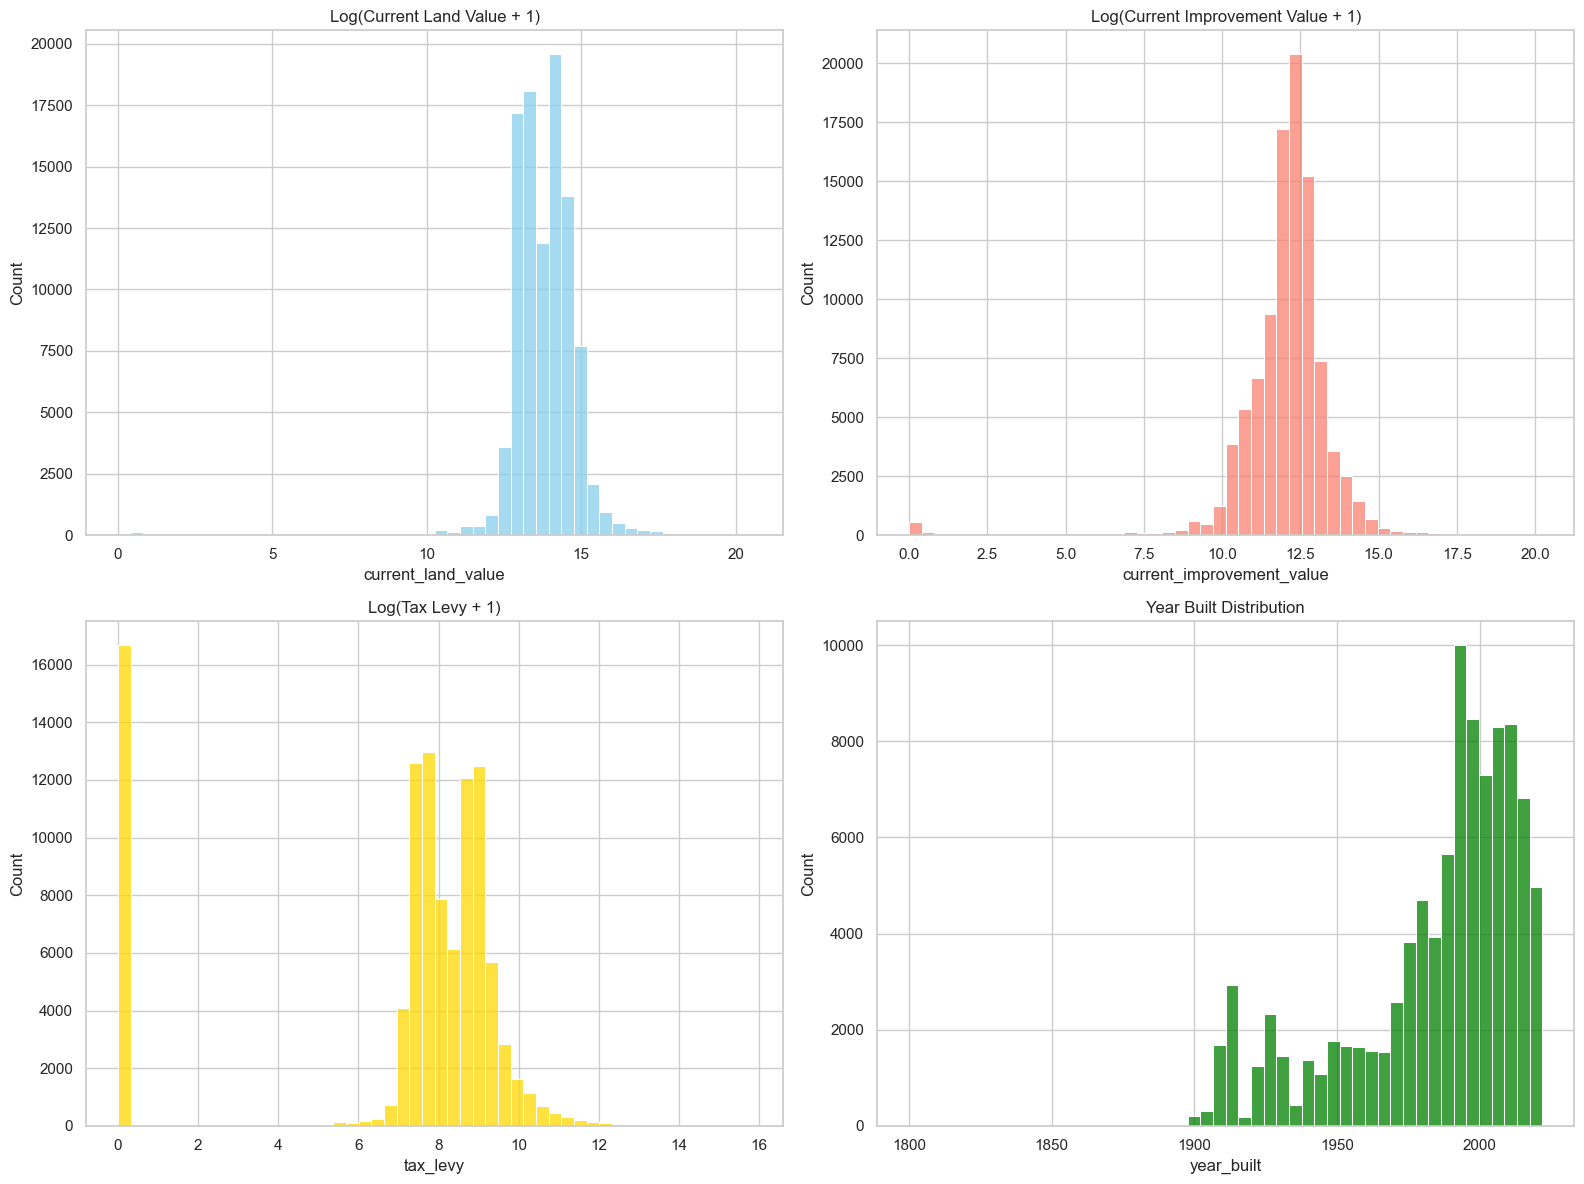

In [5]:
# Histograms for property values and year built
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Use log scale for values due to heavy right skew
df_sample = df.sample(min(len(df), 100000)) # Sample to speed up plotting if dataset is huge

sns.histplot(np.log1p(df_sample['current_land_value']), bins=50, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Log(Current Land Value + 1)')

sns.histplot(np.log1p(df_sample['current_improvement_value']), bins=50, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Log(Current Improvement Value + 1)')

sns.histplot(np.log1p(df_sample['tax_levy'].fillna(0)), bins=50, ax=axes[1,0], color='gold')
axes[1,0].set_title('Log(Tax Levy + 1)')

sns.histplot(df_sample['year_built'].dropna(), bins=50, ax=axes[1,1], color='green')
axes[1,1].set_title('Year Built Distribution')

plt.tight_layout()
plt.show()


## Outliers Detection

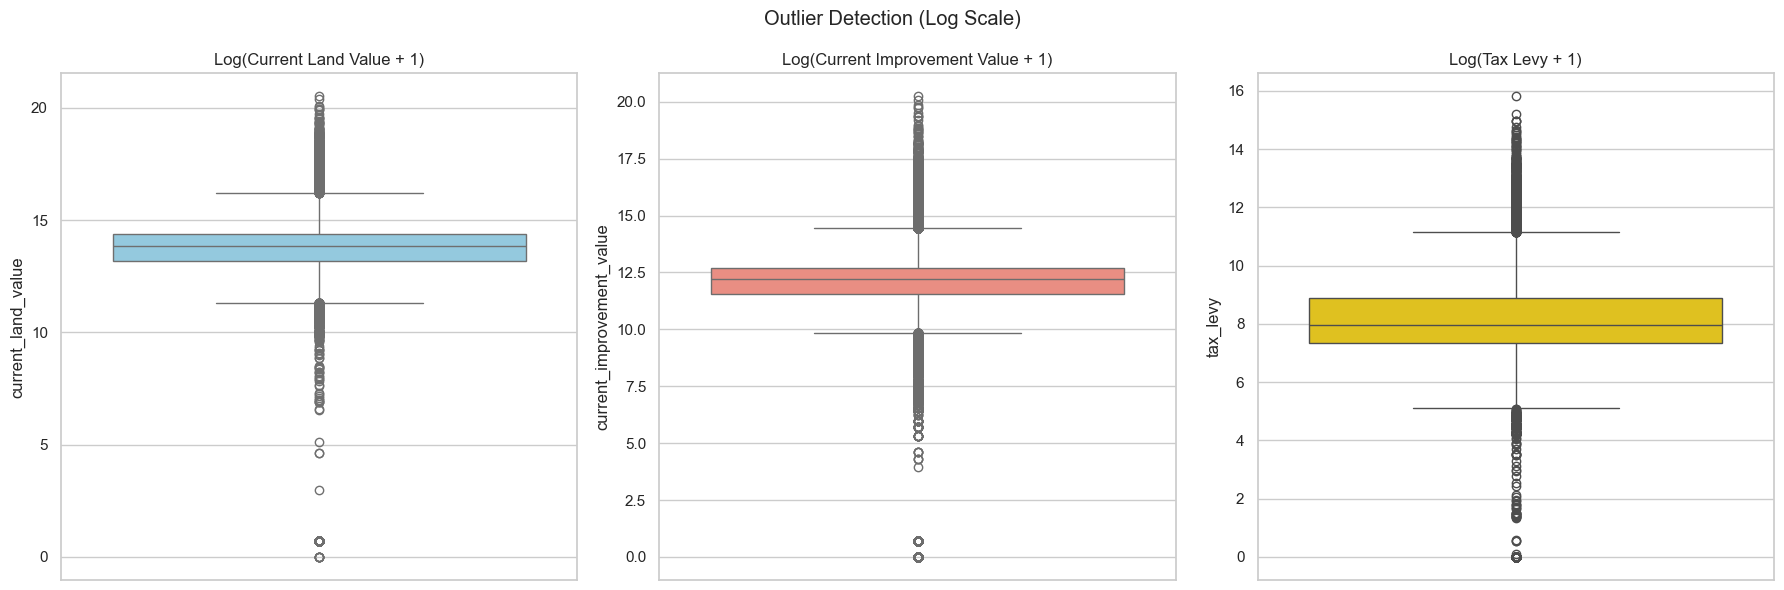

In [6]:
# Boxplots to identify outliers
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(y=np.log1p(df_sample['current_land_value']), ax=axes[0], color='skyblue')
axes[0].set_title('Log(Current Land Value + 1)')

sns.boxplot(y=np.log1p(df_sample['current_improvement_value']), ax=axes[1], color='salmon')
axes[1].set_title('Log(Current Improvement Value + 1)')

sns.boxplot(y=np.log1p(df_sample['tax_levy'].fillna(0)), ax=axes[2], color='gold')
axes[2].set_title('Log(Tax Levy + 1)')

plt.suptitle('Outlier Detection (Log Scale)')
plt.tight_layout()
plt.show()


## Correlations

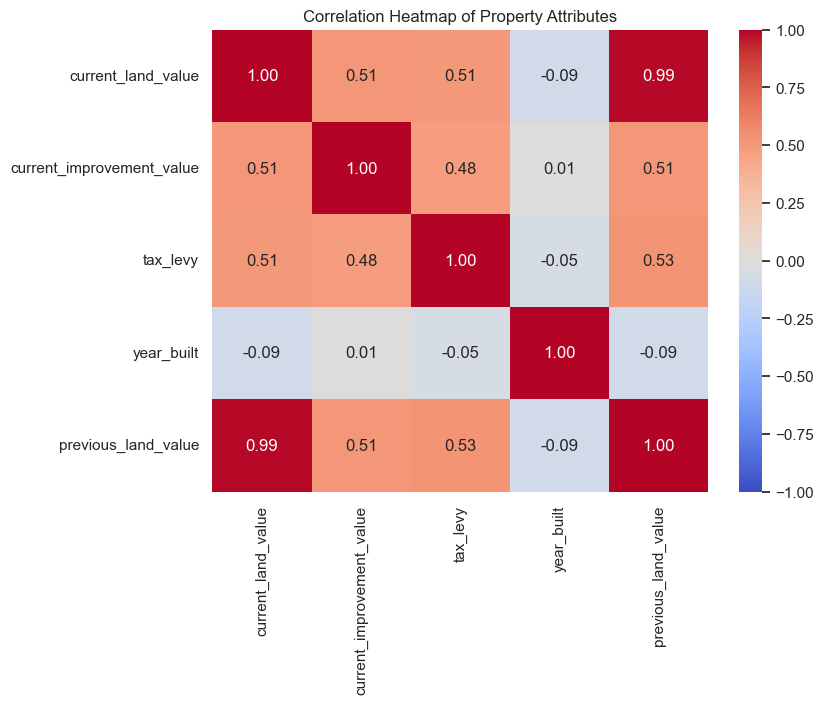

In [7]:
# Correlation heatmap
# Calculate correlation matrix
corr_matrix = df_sample[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Property Attributes')
plt.show()


## Trends over Time

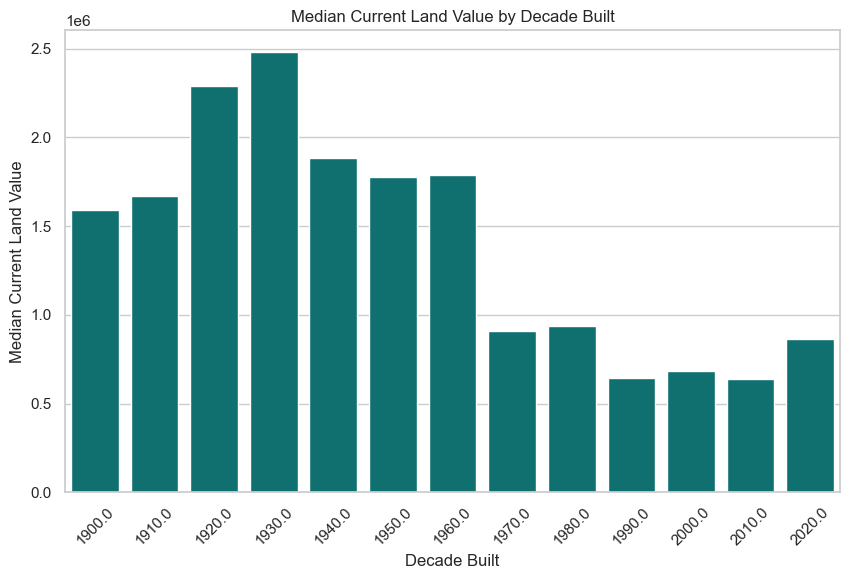

In [8]:
# Trend over time (Year Built vs Median Property Value)
# Grouping by decade to see trends
df_recent = df[df['year_built'] >= 1900].copy()
df_recent['decade_built'] = (df_recent['year_built'] // 10) * 10

decade_stats = df_recent.groupby('decade_built')['current_land_value'].median().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='decade_built', y='current_land_value', data=decade_stats, color='teal')
plt.title('Median Current Land Value by Decade Built')
plt.xlabel('Decade Built')
plt.ylabel('Median Current Land Value')
plt.xticks(rotation=45)
plt.show()
